# Principal Component Analysis (PCA) on Digits Dataset
This notebook demonstrates how PCA reduces dimensionality while preserving the most important variance in the dataset.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset
We use the Digits dataset from sklearn which contains images of handwritten digits (0–9).
Each image is represented by 64 features (8×8 pixels).

In [2]:
#sklearn have its own datasets to import data we use this syntax
from sklearn.datasets import load_digits

In [3]:
digit=load_digits()

In [4]:
digit

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [5]:
digit.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [6]:
df=pd.DataFrame(digit.data,columns=digit.feature_names)

In [7]:
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [8]:
x=digit.data
y=digit.target


In [9]:
x[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [10]:
y

array([0, 1, 2, ..., 8, 9, 8])

In [11]:
x[0].reshape(8,8)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

<Figure size 640x480 with 0 Axes>

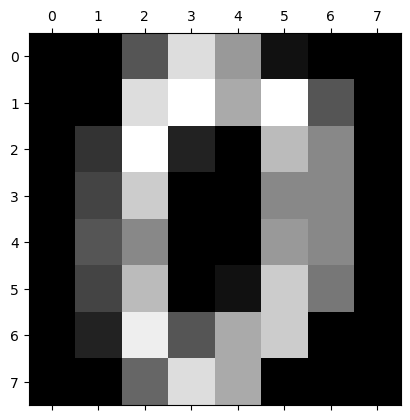

In [12]:
plt.gray()
plt.matshow(x[0].reshape(8,8))

In [13]:
y[0]

np.int64(0)

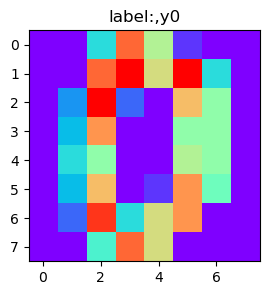

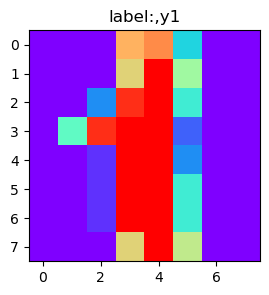

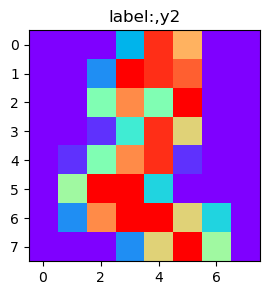

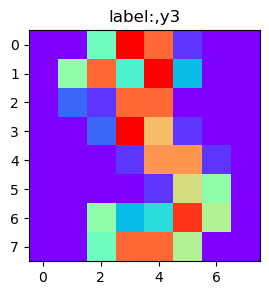

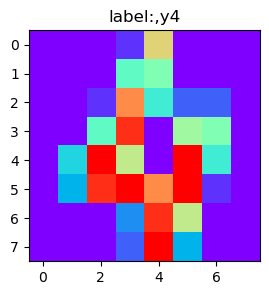

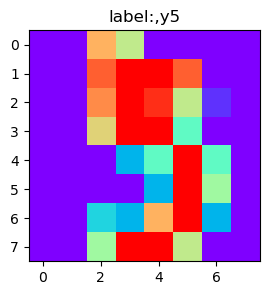

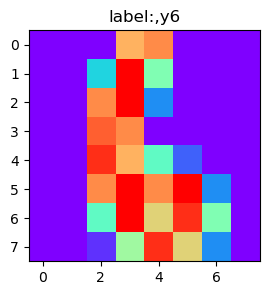

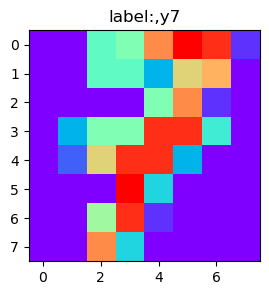

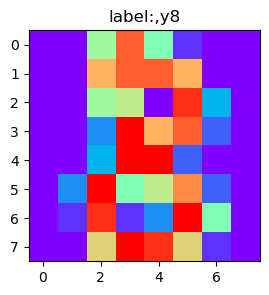

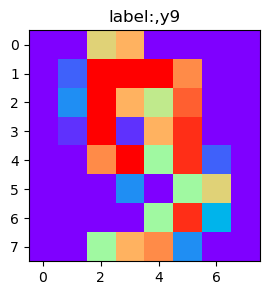

In [14]:
for i in range(10):
    plt.figure(figsize=(3,3))
    image=x[i].reshape(8,8)
    plt.imshow(image,cmap='rainbow')
    plt.title(f'label:,y{i}')
    plt.show()

In [15]:
#Implement PCA 
#Step1:Standardize the data

from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()

In [16]:
x_scaled=scalar.fit_transform(x)
x_scaled

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]])

In [17]:
#Step2: Computing the covarience matrix

covmat=np.cov(x_scaled.T)
pd.DataFrame(covmat)


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.0,1.000557,0.556928,0.207929,-0.018771,0.060810,0.048415,-0.038948,0.032338,0.556682,...,0.030970,-0.045368,-0.007910,0.856086,0.556036,0.147728,-0.102406,-0.029887,0.026562,-0.043913
2,0.0,0.556928,1.000557,0.560492,-0.084282,0.043593,0.002842,-0.062313,0.022324,0.582583,...,0.050877,-0.003806,-0.025851,0.515563,0.938145,0.500118,-0.134829,-0.041206,0.072639,0.082569
3,0.0,0.207929,0.560492,1.000557,0.023952,-0.171473,-0.115796,-0.040162,0.035683,0.328527,...,0.139475,0.075376,-0.049112,0.175902,0.560638,0.768373,-0.065993,-0.054966,0.053467,0.082016
4,0.0,-0.018771,-0.084282,0.023952,1.000557,0.508014,0.127835,0.010070,0.042089,0.051686,...,-0.265116,-0.212339,0.017362,-0.047250,-0.020187,-0.008872,-0.082171,-0.215929,-0.250838,-0.215469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.0,0.147728,0.500118,0.768373,-0.008872,-0.068076,-0.045871,0.001013,0.043398,0.305361,...,0.094770,0.050060,-0.038269,0.113035,0.481979,1.000557,0.058423,-0.095009,0.006853,0.099727
60,0.0,-0.102406,-0.134829,-0.065993,-0.082171,-0.351342,-0.383735,-0.178343,0.049024,-0.000604,...,0.394499,0.105160,0.005700,-0.117973,-0.208072,0.058423,1.000557,0.609854,0.243441,0.103073
61,0.0,-0.029887,-0.041206,-0.054966,-0.215929,-0.268967,-0.304281,-0.141253,0.033428,0.071528,...,0.707913,0.262942,-0.003058,-0.043913,-0.091890,-0.095009,0.609854,1.000557,0.648689,0.262137
62,0.0,0.026562,0.072639,0.053467,-0.250838,-0.267808,-0.179044,-0.063256,0.020700,0.111631,...,0.602602,0.512011,-0.011939,0.014565,0.035388,0.006853,0.243441,0.648689,1.000557,0.620774


In [18]:
#Step3: calculating eigen values and eigen verctors from the covarience matrix
eigenvalues, eigenvectors=np.linalg.eig(covmat)


In [19]:
pd.DataFrame(eigenvectors)

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.0
1,0.182234,-0.047027,0.023588,-0.178153,-0.029978,0.231723,-0.108310,0.125524,0.213820,0.059834,...,0.039356,-0.036629,0.082404,0.052290,0.197267,0.024853,0.052605,0.0,0.0,0.0
2,0.285868,-0.059565,-0.056799,-0.156129,-0.014666,0.119875,-0.004755,0.006178,0.120140,0.007681,...,-0.080164,0.176636,0.091203,-0.001822,-0.129372,-0.069592,-0.090823,0.0,0.0,0.0
3,0.220370,0.020804,-0.040464,-0.167800,0.043716,-0.100392,0.233717,-0.033408,-0.101895,-0.021639,...,0.125306,-0.224852,-0.089657,0.040788,-0.148353,0.052446,-0.323498,0.0,0.0,0.0
4,-0.025170,-0.155903,-0.067065,0.000009,-0.139993,-0.093471,-0.039540,0.046161,-0.093102,0.005066,...,0.049967,-0.024456,0.039529,0.012110,-0.072823,-0.057241,0.048470,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.194449,0.009905,-0.083464,-0.171490,0.100375,-0.086503,0.135319,-0.098852,-0.115978,-0.105825,...,-0.067003,0.101720,-0.245611,-0.069682,0.336075,0.080163,0.138750,0.0,0.0,0.0
60,0.017774,0.251934,-0.062455,0.154438,-0.003774,0.111832,-0.172848,-0.055067,-0.154210,-0.100353,...,-0.116854,0.219353,0.196726,0.048100,-0.189613,-0.081401,-0.036926,0.0,0.0,0.0
61,0.103198,0.242618,-0.022280,0.252432,0.094738,0.057756,-0.032155,0.034265,-0.027141,-0.036675,...,0.193102,-0.023445,0.152260,-0.131265,-0.019375,-0.033929,-0.168659,0.0,0.0,0.0
62,0.119811,0.165089,0.100366,0.160720,0.244026,0.028957,0.077612,-0.164484,0.144245,0.057176,...,0.067240,0.095552,-0.207269,0.284186,0.086148,-0.141619,0.094642,0.0,0.0,0.0


In [20]:
total=sum(eigenvalues)
total

np.float64(61.03396436525628)

In [21]:
#Explained Variance
exp_var=[]
for i in sorted(eigenvalues,reverse=True):
    exp_var.append((i/total)*100)

exp_var




[np.float64(12.033916097734904),
 np.float64(9.56105440309786),
 np.float64(8.444414892624561),
 np.float64(6.498407907524172),
 np.float64(4.860154875966422),
 np.float64(4.2141198692719595),
 np.float64(3.942082803567383),
 np.float64(3.389380924638334),
 np.float64(2.998221011625217),
 np.float64(2.932002551252206),
 np.float64(2.7818054635503264),
 np.float64(2.577055092582002),
 np.float64(2.2753033157642535),
 np.float64(2.2271797395143533),
 np.float64(2.1652294318492364),
 np.float64(1.9141666064421348),
 np.float64(1.775547085168193),
 np.float64(1.6380692742844223),
 np.float64(1.5964601688623374),
 np.float64(1.4891911870878232),
 np.float64(1.3479695658179363),
 np.float64(1.2719313702347588),
 np.float64(1.16583735059195),
 np.float64(1.0576465985363197),
 np.float64(0.9753159471981144),
 np.float64(0.9445589897319995),
 np.float64(0.8630138269707264),
 np.float64(0.8366428536685128),
 np.float64(0.7976932484112442),
 np.float64(0.7464713709260629),
 np.float64(0.725582151

In [22]:
#Cumlative explained variance
cum_var=np.cumsum(exp_var)
pd.DataFrame(cum_var)

,0
0,12.033916
1,21.594971
2,30.039385
3,36.537793
4,41.397948
...,...
59,99.917465
60,100.000000
61,100.000000
62,100.000000


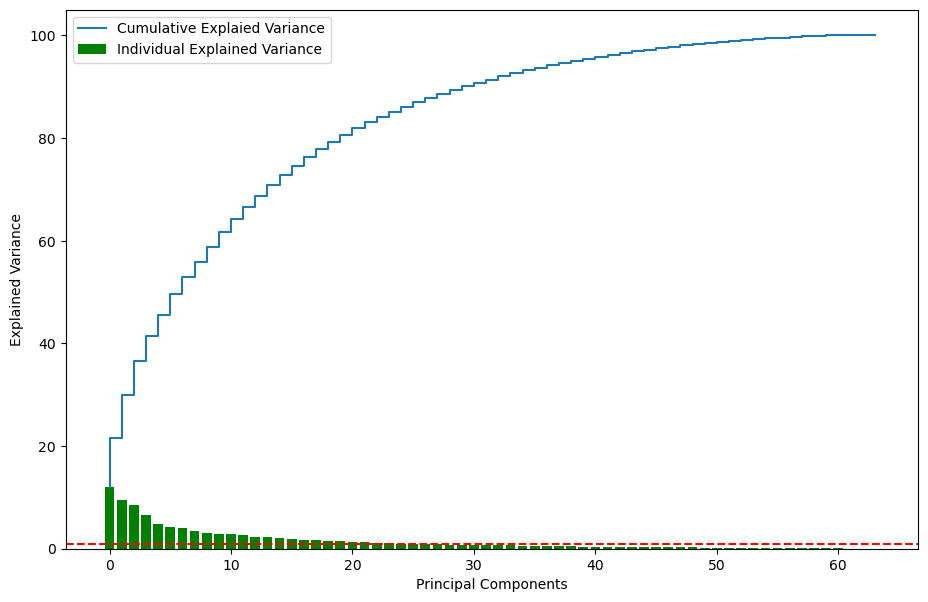

In [23]:
#Scree plot
plt.figure(figsize=(11,7))
plt.bar(range(len(exp_var)), exp_var,label="Individual Explained Variance",color="g")
plt.step(range(len(exp_var)), cum_var,label="Cumulative Explaied Variance")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.axhline(y=1,color="red",linestyle="--")
plt.legend()
plt.show()




## Applying Principal Component Analysis
PCA is used to reduce the number of features while preserving the most important information.

In [24]:
from sklearn.decomposition import PCA

In [25]:
pca=PCA(0.95)
x_pca=pca.fit_transform(x)
x_pca.shape

(1797, 29)

In [26]:
pd.DataFrame(x_pca)

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,-1.259466,-21.274883,9.463055,-13.014189,7.128823,7.440659,-3.252837,-2.553470,0.581842,-3.625697,...,3.462119,2.680850,1.009450,2.009703,1.295315,1.178879,2.300582,3.670721,0.943669,1.132502
1,7.957611,20.768699,-4.439506,14.893664,-5.896249,6.485622,-2.126228,4.615936,-3.587450,1.074705,...,5.255708,-1.205777,-4.838902,0.860251,-2.974439,5.288817,0.119213,2.182618,0.510227,-2.313549
2,6.991923,9.955986,-2.958558,12.288302,18.126023,4.507664,-1.843122,16.415200,-0.719233,-4.255805,...,-8.731076,4.951115,-2.465109,5.999388,0.105727,-3.062671,0.166046,4.228821,-2.157657,-0.837958
3,-15.906105,-3.332464,-9.824372,12.275838,-6.965169,-1.089483,1.042085,-10.973556,3.259735,-6.498753,...,3.876889,0.269413,3.623236,2.538124,-1.354896,-1.740973,-1.340244,-5.846014,-4.682220,1.113042
4,23.306867,-4.269061,5.675129,13.851524,0.358124,2.857574,0.720497,-13.041696,3.835413,-13.414164,...,-5.035236,0.206830,5.740696,-7.611946,3.991408,2.781007,-0.166739,0.484305,-0.627979,3.287348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,-14.606628,-13.344124,13.439048,6.502950,-3.787472,2.729848,4.432327,3.914347,-7.320933,8.449179,...,-1.613182,1.732102,2.198947,0.273557,2.325997,0.547892,-2.445219,4.914990,0.183197,2.788351
1793,6.464574,-20.567299,9.155110,-12.554091,9.015978,13.707147,-3.831286,3.756258,7.192802,5.239837,...,0.317365,-3.994398,-1.577277,-0.578987,1.222268,2.432416,-1.134583,-0.048710,0.304789,3.483718
1794,10.801284,6.960252,-5.599555,7.227733,3.459646,12.375204,4.489790,7.415072,3.961585,13.065095,...,-2.400419,-0.732898,4.330780,0.180299,3.817864,-5.421945,4.431521,-3.568662,-1.824444,-3.538859
1795,-4.872100,-12.423954,10.170866,6.668850,-3.569061,0.003897,2.994734,4.357892,-3.939242,13.145255,...,0.076164,1.871624,-1.486850,3.125878,-3.757649,5.096836,-2.690764,3.253301,-0.954842,0.938956


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [28]:
xtrain,xtest,ytrain,ytest=train_test_split(x_pca,y,test_size=0.2,random_state=42)

In [29]:
model=LogisticRegression()

In [30]:
model.fit(xtrain,ytrain)

c:\Users\ronit\anaconda3\ronitana\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [31]:
ypred=model.predict(xtest)

In [32]:
ypred

array([6, 9, 3, 7, 3, 1, 5, 2, 5, 2, 1, 1, 4, 0, 4, 2, 3, 7, 8, 8, 4, 3,
       9, 7, 5, 6, 3, 5, 6, 3, 4, 9, 2, 4, 4, 6, 9, 4, 7, 6, 6, 9, 1, 3,
       6, 1, 3, 0, 6, 5, 5, 1, 3, 5, 6, 0, 9, 0, 0, 1, 0, 4, 5, 2, 4, 5,
       7, 0, 7, 5, 9, 5, 5, 4, 7, 0, 4, 5, 5, 9, 9, 0, 2, 3, 8, 0, 6, 4,
       4, 9, 1, 2, 8, 3, 5, 2, 9, 0, 4, 4, 4, 3, 5, 3, 1, 3, 5, 9, 4, 2,
       7, 7, 4, 4, 1, 9, 2, 7, 8, 7, 2, 6, 9, 4, 0, 7, 2, 7, 5, 8, 7, 5,
       7, 5, 0, 6, 6, 4, 2, 8, 0, 9, 4, 6, 9, 9, 6, 9, 0, 5, 5, 6, 6, 0,
       6, 4, 3, 9, 3, 8, 7, 2, 9, 0, 4, 5, 3, 6, 5, 9, 9, 8, 4, 2, 1, 3,
       7, 7, 2, 2, 3, 9, 8, 0, 3, 2, 2, 5, 6, 9, 9, 4, 1, 2, 4, 2, 3, 6,
       4, 8, 5, 9, 5, 7, 8, 9, 4, 8, 1, 5, 4, 4, 9, 6, 1, 8, 6, 0, 4, 5,
       2, 7, 1, 6, 4, 5, 6, 0, 3, 2, 3, 6, 7, 1, 9, 1, 4, 7, 6, 5, 8, 5,
       5, 1, 5, 1, 8, 8, 9, 9, 7, 6, 2, 2, 2, 3, 4, 8, 8, 3, 6, 0, 9, 7,
       7, 0, 1, 0, 4, 5, 1, 5, 3, 6, 0, 4, 1, 0, 0, 3, 6, 5, 9, 7, 3, 5,
       5, 9, 9, 8, 5, 3, 3, 2, 0, 5, 8, 3, 4, 0, 2,

In [33]:
from sklearn.metrics import*

In [34]:
accuracy_score(ypred,ytest)

0.9611111111111111